In [1]:
import os
import random
import numpy as np
import pandas as pd

SEED = 123

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# =========================================================
# STEP 1 — Load data and integrity checks
# Model 01: TF-IDF + Logistic Regression
# =========================================================

CSV_PATH = "../Dati/Processed/dataset_processed_quantile1_sentences.csv"

KEEP_COLS = [
    "article_id",
    "topic_id",
    "binary_label",
    "fold",
    "text_bert"
]

# Load dataset
df = pd.read_csv(CSV_PATH)
df = df[KEEP_COLS].copy()
df = df.reset_index(drop=True)

# -----------------------------
# Integrity checks
# -----------------------------

print(f"[shape] {df.shape[0]} docs, {df.shape[1]} cols")

print("\n[missing values]")
print(df.isna().sum())

print(f"\n[duplicate article_id] {df['article_id'].duplicated().sum()}")

print(f"\n[folds] {sorted(df['fold'].unique())}")

# -----------------------------
# Label distribution
# -----------------------------

print("\n[label balance overall]")
print(
    df["binary_label"]
      .value_counts(normalize=True)
      .round(3)
      .to_dict()
)

print("\n[label balance per fold]")
print(
    df.groupby("fold")["binary_label"]
      .value_counts(normalize=True)
      .round(2)
      .unstack()
)

print("\n[documents per fold]")
print(
    df["fold"]
      .value_counts()
      .sort_index()
      .to_dict()
)

# -----------------------------
# Text length statistics
# -----------------------------

text_len = df["text_bert"].str.split().str.len()

print("\n[text length (words)]")
print(text_len.describe().round(1))

[shape] 624 docs, 5 cols

[missing values]
article_id      0
topic_id        0
binary_label    0
fold            0
text_bert       0
dtype: int64

[duplicate article_id] 0

[folds] [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

[label balance overall]
{1: 0.667, 0: 0.333}

[label balance per fold]
binary_label     0     1
fold                    
0             0.33  0.67
1             0.33  0.67
2             0.33  0.67
3             0.33  0.67
4             0.33  0.67

[documents per fold]
{0: 126, 1: 126, 2: 126, 3: 123, 4: 123}

[text length (words)]
count     624.0
mean      184.4
std       134.2
min        28.0
25%       100.8
50%       160.0
75%       239.5
max      1278.0
Name: text_bert, dtype: float64


In [9]:
# =========================================================
# STEP 2 — TF-IDF + Logistic Regression pipeline
# Model 01: TF-IDF + Logistic Regression
# =========================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(2, 5),
        min_df=2,              #
        sublinear_tf=True,
        lowercase=True,
        strip_accents="unicode"
    ),
    ),
    (
        "clf",
        LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=SEED
        )
    )
])

print(pipeline)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char_wb', min_df=2,
                                 ngram_range=(2, 5), strip_accents='unicode',
                                 sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=123))])


In [10]:
# =========================================================
# STEP 3 — Grid Search
# Model 01: TF-IDF + Logistic Regression
# =========================================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Hyperparameter grid
param_grid = {

    # ----- TF-IDF -----
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "tfidf__min_df": [
        2,
        3
    ],

    "tfidf__max_df": [
        0.90,
        0.95
    ],

    "tfidf__sublinear_tf": [
        True,
        False
    ],

    "tfidf__max_features": [
        3000,
        5000
    ],

    # ----- Logistic Regression -----
    "clf__C": [
        0.01,
        0.1,
        1,
        10
    ],

    "clf__solver": [
        "liblinear"
    ],

    "clf__penalty": [
        "l2"
    ]
}

# Inner CV (used only on the training portion of each outer fold)
inner_cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=SEED
)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=inner_cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

print(f"Number of parameter combinations: {len(grid.param_grid)}")

from sklearn.model_selection import ParameterGrid
print(f"Parameter combinations: {len(ParameterGrid(param_grid))}")

Number of parameter combinations: 8
Parameter combinations: 128


In [11]:
# =========================================================
# STEP 4 — 5-fold CV with Grid Search
# Model 01: TF-IDF + Logistic Regression
# =========================================================

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report
)

oof_rows = []
fold_scores = []

N_FOLDS = 5

for fold in range(N_FOLDS):

    print("=" * 60)
    print(f"FOLD {fold}")
    print("=" * 60)

    # -------------------------
    # Train / Test split
    # -------------------------

    train = df[df["fold"] != fold].copy()
    test  = df[df["fold"] == fold].copy()

    X_train = train["text_bert"]
    y_train = train["binary_label"]

    X_test = test["text_bert"]
    y_test = test["binary_label"]

    # -------------------------
    # Grid Search
    # -------------------------

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    print("\nBest parameters:")
    print(grid.best_params_)

    print(f"Best inner CV Macro F1: {grid.best_score_:.4f}")

    # -------------------------
    # Prediction
    # -------------------------

    y_pred = best_model.predict(X_test)

    y_prob = best_model.predict_proba(X_test)[:, 1]

    # -------------------------
    # Metrics
    # -------------------------

    fold_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    fold_acc = accuracy_score(
        y_test,
        y_pred
    )

    fold_scores.append(fold_f1)

    print(f"\nMacro F1 : {fold_f1:.4f}")
    print(f"Accuracy : {fold_acc:.4f}")

    print("\nClassification report")
    print(classification_report(y_test, y_pred, digits=3))

    

    # -------------------------
    # Save OOF predictions
    # -------------------------

    for aid, yt, yp, pr in zip(
        test["article_id"],
        y_test,
        y_pred,
        y_prob
    ):

        oof_rows.append({

            "article_id": aid,
            "fold": fold,
            "y_true": int(yt),
            "y_pred": int(yp),
            "prob_class1": float(pr)

        })



FOLD 0
Fitting 4 folds for each of 128 candidates, totalling 512 fits

Best parameters:
{'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'tfidf__max_df': 0.95, 'tfidf__max_features': 3000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True}
Best inner CV Macro F1: 0.5748

Macro F1 : 0.6345
Accuracy : 0.6429

Classification report
              precision    recall  f1-score   support

           0      0.477     0.738     0.579        42
           1      0.820     0.595     0.690        84

    accuracy                          0.643       126
   macro avg      0.648     0.667     0.635       126
weighted avg      0.705     0.643     0.653       126

FOLD 1
Fitting 4 folds for each of 128 candidates, totalling 512 fits

Best parameters:
{'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'tfidf__max_df': 0.95, 'tfidf__max_features': 3000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True}
Best inner CV M

In [12]:
# =========================================================
# STEP 5 — Overall CV results
# Model 01: TF-IDF + Logistic Regression
# =========================================================

oof_df = pd.DataFrame(oof_rows)

print("\n" + "=" * 60)
print("CROSS-VALIDATION RESULTS")
print("=" * 60)

print(f"Macro F1 per fold : {[round(s, 4) for s in fold_scores]}")

print(
    f"Macro F1 mean ± std : "
    f"{np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}"
)

print(f"\nOOF predictions: {len(oof_df)}")
print(f"Dataset size    : {len(df)}")

assert len(oof_df) == len(df), "Missing OOF predictions!"

# ---------------------------------------------------------
# Overall metrics from OOF predictions
# ---------------------------------------------------------

print("\nOverall OOF performance")

print(
    classification_report(
        oof_df["y_true"],
        oof_df["y_pred"],
        digits=3
    )
)

overall_f1 = f1_score(
    oof_df["y_true"],
    oof_df["y_pred"],
    average="macro"
)

overall_acc = accuracy_score(
    oof_df["y_true"],
    oof_df["y_pred"]
)

print(f"Overall Macro F1 : {overall_f1:.4f}")
print(f"Overall Accuracy : {overall_acc:.4f}")


CROSS-VALIDATION RESULTS
Macro F1 per fold : [0.6345, 0.5984, 0.53, 0.5659, 0.6108]
Macro F1 mean ± std : 0.5879 ± 0.0365

OOF predictions: 624
Dataset size    : 624

Overall OOF performance
              precision    recall  f1-score   support

           0      0.442     0.529     0.481       208
           1      0.739     0.666     0.700       416

    accuracy                          0.620       624
   macro avg      0.590     0.597     0.591       624
weighted avg      0.640     0.620     0.627       624

Overall Macro F1 : 0.5909
Overall Accuracy : 0.6202


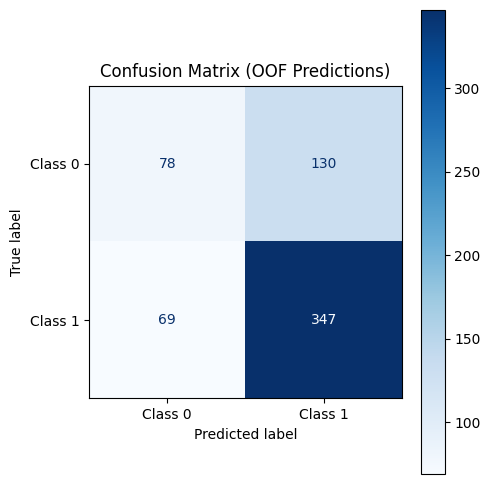

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(5, 5))

ConfusionMatrixDisplay.from_predictions(
    oof_df["y_true"],
    oof_df["y_pred"],
    display_labels=["Class 0", "Class 1"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Confusion Matrix (OOF Predictions)")

plt.tight_layout()
plt.show()